# E2 — Notebook 02: Datos, EDA y Balance
## LaLonde/NSW — ICA 2026-I

**Objetivo:** Carga de los tres datasets, estadísticas descriptivas, SMD y análisis de soporte común.

**Benchmark RCT:** ATT = $1,794 (SE ≈ $632) — LaLonde (1986)

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
# Asegurar que el cwd sea la raíz del proyecto
from pathlib import Path
_root = Path(os.getcwd())
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from lalonde_nsw.data import (
    guardar_procesados, smd, COVARIABLES
)
from lalonde_nsw.visualization import love_plot, overlap_plot, distribucion_outcome, tabla_smd_styled
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('Setup OK. RANDOM_STATE =', RANDOM_STATE)

Setup OK. RANDOM_STATE = 42


## 1. Carga de datos

In [2]:
datasets = guardar_procesados()
df_exp   = datasets['experimental']
df_cps1  = datasets['obs_cps1']
df_psid1 = datasets['obs_psid1']

for nombre, df in datasets.items():
    n_t = (df['treat'] == 1).sum()
    n_c = (df['treat'] == 0).sum()
    print(f'{nombre:15s}: {len(df):6,} obs  |  tratados={n_t:4,}  controles={n_c:6,}')

experimental   :    445 obs  |  tratados= 185  controles=   260
obs_cps1       : 16,177 obs  |  tratados= 185  controles=15,992
obs_psid1      :  2,675 obs  |  tratados= 185  controles= 2,490


In [3]:
df_exp.head()

,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1,37.0,11.0,1,0,1,1,0.0,0.0,9930.045898
1,1,22.0,9.0,0,1,0,1,0.0,0.0,3595.894043
2,1,30.0,12.0,1,0,0,0,0.0,0.0,24909.449219
3,1,27.0,11.0,1,0,0,1,0.0,0.0,7506.145996
4,1,33.0,8.0,1,0,0,1,0.0,0.0,289.789886


## 2. Estadísticas descriptivas por grupo

In [4]:
def resumen_grupo(df, nombre):
    cols = COVARIABLES + ['re78']
    trat = df[df['treat']==1][cols]
    ctrl = df[df['treat']==0][cols]
    res = pd.DataFrame({
        'Tratados (media)':  trat.mean().round(2),
        'Tratados (SD)':     trat.std().round(2),
        'Controles (media)': ctrl.mean().round(2),
        'Controles (SD)':    ctrl.std().round(2),
    })
    print(f'=== {nombre} (T={len(trat):,}, C={len(ctrl):,}) ===')
    return res

resumen_grupo(df_exp, 'Experimental RCT')

=== Experimental RCT (T=185, C=260) ===


,Tratados (media),Tratados (SD),Controles (media),Controles (SD)
age,25.82,7.16,25.05,7.06
educ,10.35,2.01,10.09,1.61
black,0.84,0.36,0.83,0.38
hisp,0.06,0.24,0.11,0.31
married,0.19,0.39,0.15,0.36
nodegree,0.71,0.46,0.83,0.37
re74,2095.57,4886.62,2107.03,5687.91
re75,1532.06,3219.25,1266.91,3102.98
re78,6349.14,7867.40,4554.80,5483.84


In [5]:
resumen_grupo(df_cps1, 'Observacional CPS1')

=== Observacional CPS1 (T=185, C=15,992) ===


,Tratados (media),Tratados (SD),Controles (media),Controles (SD)
age,25.82,7.16,33.23,11.05
educ,10.35,2.01,12.03,2.87
black,0.84,0.36,0.07,0.26
hisp,0.06,0.24,0.07,0.26
married,0.19,0.39,0.71,0.45
nodegree,0.71,0.46,0.30,0.46
re74,2095.57,4886.62,14016.80,9569.80
re75,1532.06,3219.25,13650.80,9270.40
re78,6349.14,7867.40,14846.66,9647.39


In [6]:
resumen_grupo(df_psid1, 'Observacional PSID1')

=== Observacional PSID1 (T=185, C=2,490) ===


,Tratados (media),Tratados (SD),Controles (media),Controles (SD)
age,25.82,7.16,34.85,10.44
educ,10.35,2.01,12.12,3.08
black,0.84,0.36,0.25,0.43
hisp,0.06,0.24,0.03,0.18
married,0.19,0.39,0.87,0.34
nodegree,0.71,0.46,0.31,0.46
re74,2095.57,4886.62,19428.75,13406.88
re75,1532.06,3219.25,19063.34,13596.95
re78,6349.14,7867.40,21553.92,15555.35


## 3. SMD — Balance de covariables

La Diferencia Estandarizada de Medias (SMD) mide el desequilibrio entre grupos.
|SMD| < 0.10 se considera balance adecuado (Austin 2009).

In [7]:
smd_exp   = smd(df_exp)
smd_cps1  = smd(df_cps1)
smd_psid1 = smd(df_psid1)

print('SMD Experimental (RCT):')
print(smd_exp.to_string())
print(f'Max |SMD|: {smd_exp["SMD"].abs().max():.3f}')

SMD Experimental (RCT):
            mean_treat  mean_control    SMD
covariable                                 
age             25.816        25.054  0.107
educ            10.346        10.088  0.141
black            0.843         0.827  0.044
hisp             0.059         0.108 -0.175
married          0.189         0.154  0.094
nodegree         0.708         0.835 -0.304
re74          2095.574      2107.027 -0.002
re75          1532.055      1266.909  0.084
Max |SMD|: 0.304


In [8]:
print('SMD CPS1:')
print(smd_cps1.to_string())
print(f'Max |SMD|: {smd_cps1["SMD"].abs().max():.3f}')

SMD CPS1:
            mean_treat  mean_control    SMD
covariable                                 
age             25.816        33.225 -0.796
educ            10.346        12.028 -0.679
black            0.843         0.074  2.428
hisp             0.059         0.072 -0.051
married          0.189         0.712 -1.233
nodegree         0.708         0.296  0.904
re74          2095.574     14016.800 -1.569
re75          1532.055     13650.804 -1.746
Max |SMD|: 2.428


In [9]:
print('SMD PSID1:')
print(smd_psid1.to_string())
print(f'Max |SMD|: {smd_psid1["SMD"].abs().max():.3f}')

SMD PSID1:
            mean_treat  mean_control    SMD
covariable                                 
age             25.816        34.851 -1.009
educ            10.346        12.117 -0.681
black            0.843         0.251  1.480
hisp             0.059         0.033  0.129
married          0.189         0.866 -1.842
nodegree         0.708         0.305  0.879
re74          2095.574     19428.746 -1.718
re75          1532.055     19063.338 -1.774
Max |SMD|: 1.842


In [10]:
tabla_smd_styled(smd_cps1)

,mean_treat,mean_control,SMD
covariable,,,
age,25.816,33.225,-0.796
educ,10.346,12.028,-0.679
black,0.843,0.074,2.428
hisp,0.059,0.072,-0.051
married,0.189,0.712,-1.233
nodegree,0.708,0.296,0.904
re74,2095.574,14016.800,-1.569
re75,1532.055,13650.804,-1.746


## 4. Love Plots

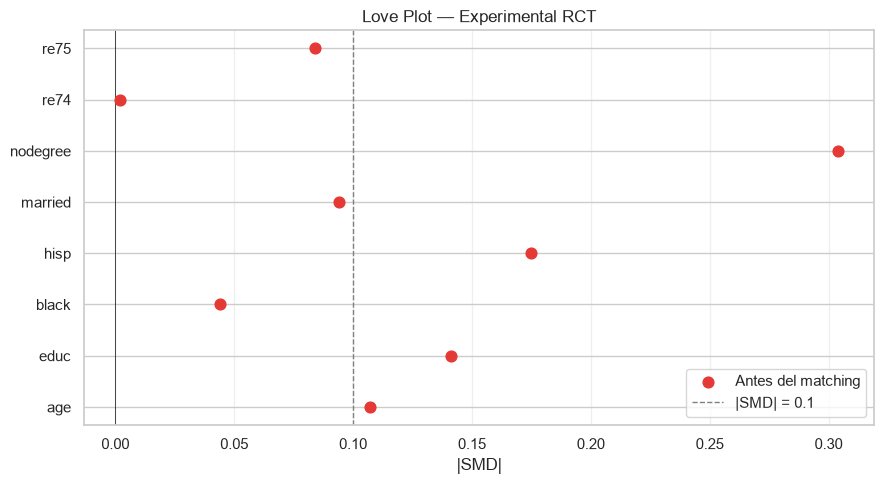

In [11]:
fig, _ = love_plot(smd_exp, titulo='Love Plot — Experimental RCT')
plt.show()

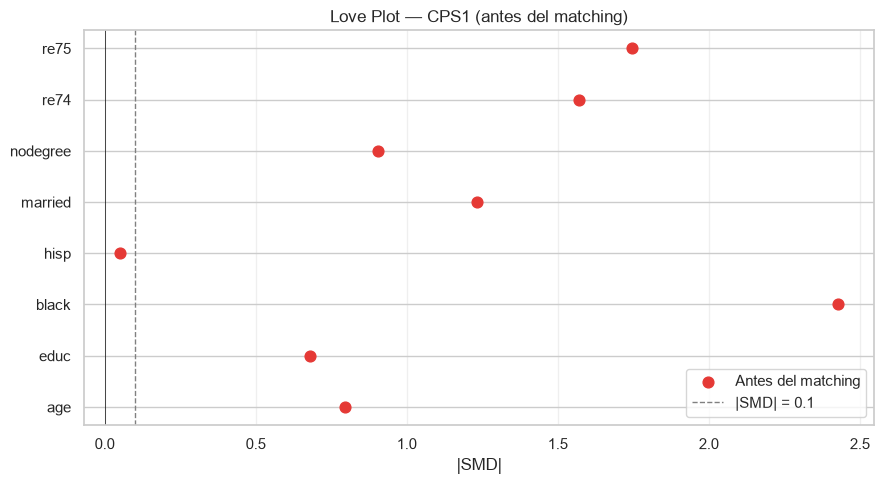

In [12]:
fig, _ = love_plot(smd_cps1, titulo='Love Plot — CPS1 (antes del matching)')
plt.show()

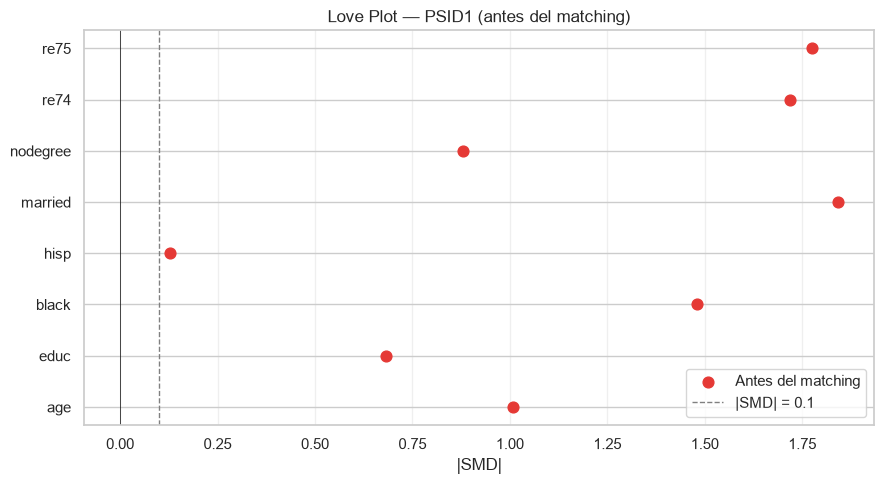

In [13]:
fig, _ = love_plot(smd_psid1, titulo='Love Plot — PSID1 (antes del matching)')
plt.show()

## 5. Propensity Score y soporte común

In [14]:
def estimar_ps_lr(df):
    X = StandardScaler().fit_transform(df[COVARIABLES].values.astype(float))
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X, df['treat'].values)
    return lr.predict_proba(X)[:, 1]

df_cps1_ps  = df_cps1.copy();  df_cps1_ps['ps']  = estimar_ps_lr(df_cps1)
df_psid1_ps = df_psid1.copy(); df_psid1_ps['ps'] = estimar_ps_lr(df_psid1)

for nombre, dfps in [('CPS1', df_cps1_ps), ('PSID1', df_psid1_ps)]:
    stats = dfps.groupby('treat')['ps'].describe()[['mean','min','max']].round(3)
    print(f'\n--- PS {nombre} ---')
    print(stats)


--- PS CPS1 ---
        mean    min    max
treat                     
0      0.008  0.000  0.480
1      0.268  0.001  0.479

--- PS PSID1 ---
        mean    min    max
treat                     
0      0.028  0.000  0.898
1      0.623  0.001  0.921


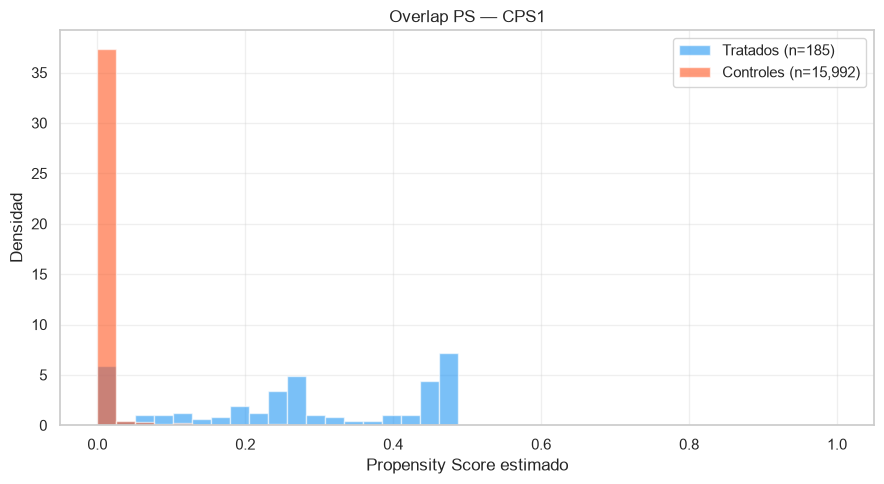

In [15]:
fig, _ = overlap_plot(df_cps1_ps, titulo='Overlap PS — CPS1')
plt.show()

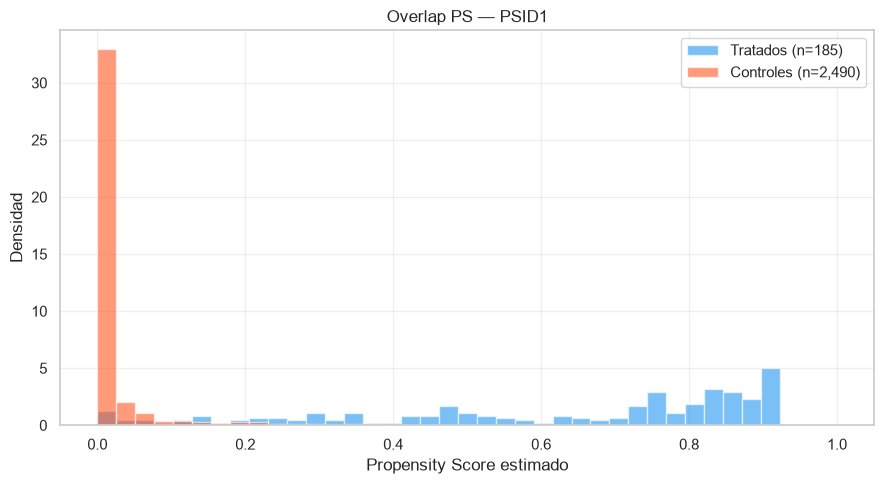

In [16]:
fig, _ = overlap_plot(df_psid1_ps, titulo='Overlap PS — PSID1')
plt.show()

## 6. Distribución de re78 y diferencia naive

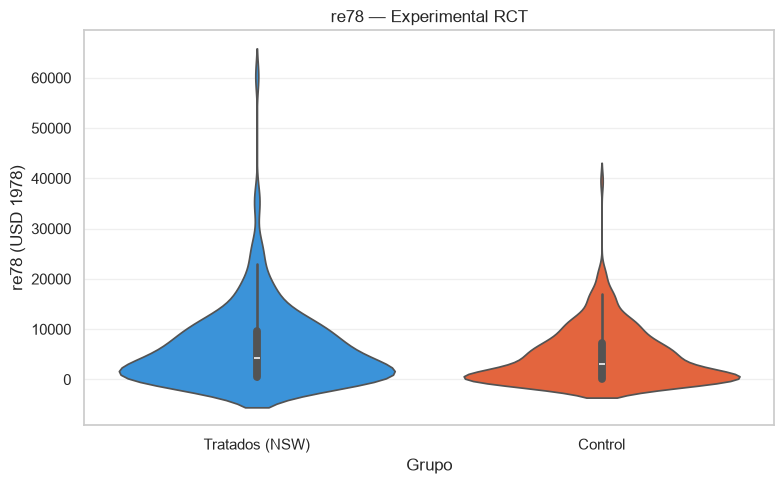


=== Diferencia naive de medias en re78 ===
Experimental: $   1,794  (sesgo vs RCT $1,794: $+0)
CPS1        : $  -8,498  (sesgo vs RCT $1,794: $-10,292)
PSID1       : $ -15,205  (sesgo vs RCT $1,794: $-16,999)


In [17]:
fig, _ = distribucion_outcome(df_exp, titulo='re78 — Experimental RCT')
plt.show()

print('\n=== Diferencia naive de medias en re78 ===')
for nombre, df in [('Experimental', df_exp), ('CPS1', df_cps1), ('PSID1', df_psid1)]:
    diff = df[df['treat']==1]['re78'].mean() - df[df['treat']==0]['re78'].mean()
    print(f'{nombre:12s}: ${diff:8,.0f}  (sesgo vs RCT $1,794: ${diff-1794:+,.0f})')

## Resumen del análisis de balance

| Dataset | N | Tratados | Max |SMD| | Diff. naive re78 |
|---------|---|----------|-------------|------------------|
| Experimental (RCT) | 445 | 185 | < 0.10 | ~ $1,794 |
| Observacional CPS1 | 16,177 | 185 | > 1.0 | Sesgado |
| Observacional PSID1 | 2,675 | 185 | > 0.5 | Sesgado |

**Conclusiones:**
- El RCT tiene balance perfecto, confirmando la aleatorización.
- CPS1 y PSID1 tienen desequilibrio severo; la diferencia naive subestima fuertemente el efecto.
- El soporte común en CPS1 es muy limitado: necesitamos PSM y AIPW.

→ **Próximo paso:** Notebook 03 — Estimación con PSM y AIPW.